Codigo para la práctica:
Gracida Salgado Angel David


1) Grafica las intensidades en función de los angulos

<>:58: SyntaxWarning: invalid escape sequence '\o'
<>:58: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-2005049095.py:58: SyntaxWarning: invalid escape sequence '\o'
  return f"$\overline{{{-n}}}$" #si es negativo ponle gorrito
/tmp/ipython-input-2005049095.py:88: RuntimeWarning: invalid value encountered in arcsin
  theta2=2*np.arcsin(((lamb)*NG)/(4*np.pi))*(180/np.pi) #se calcula 2*angulo en grados


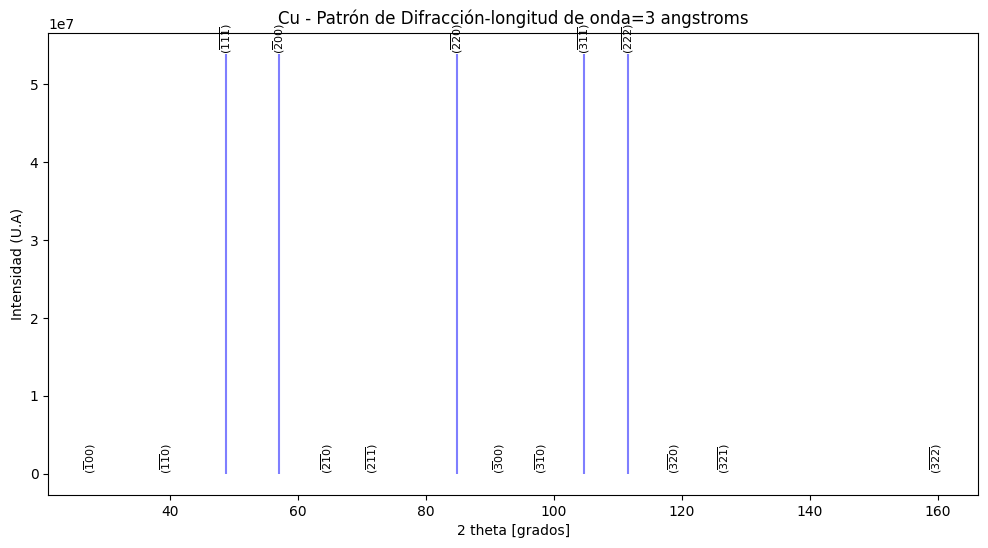

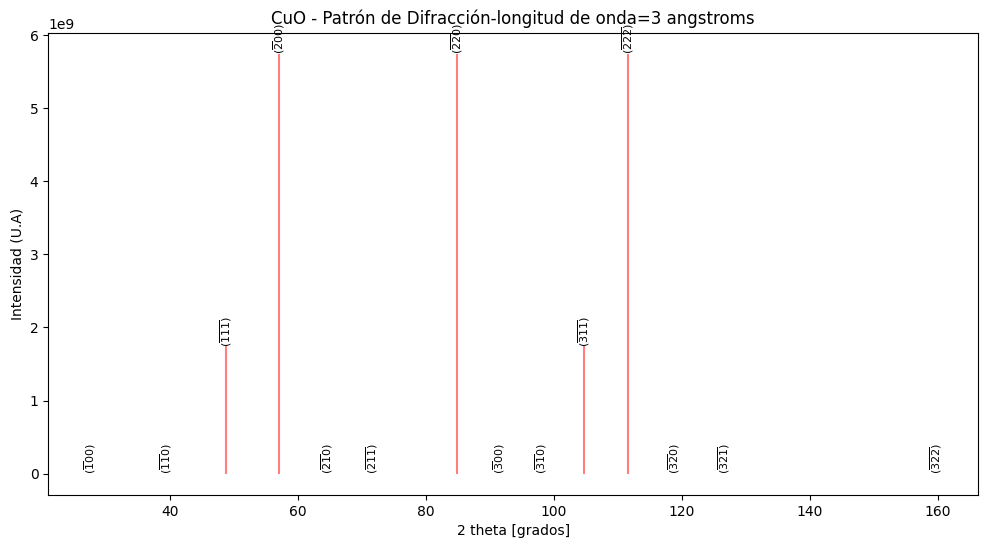

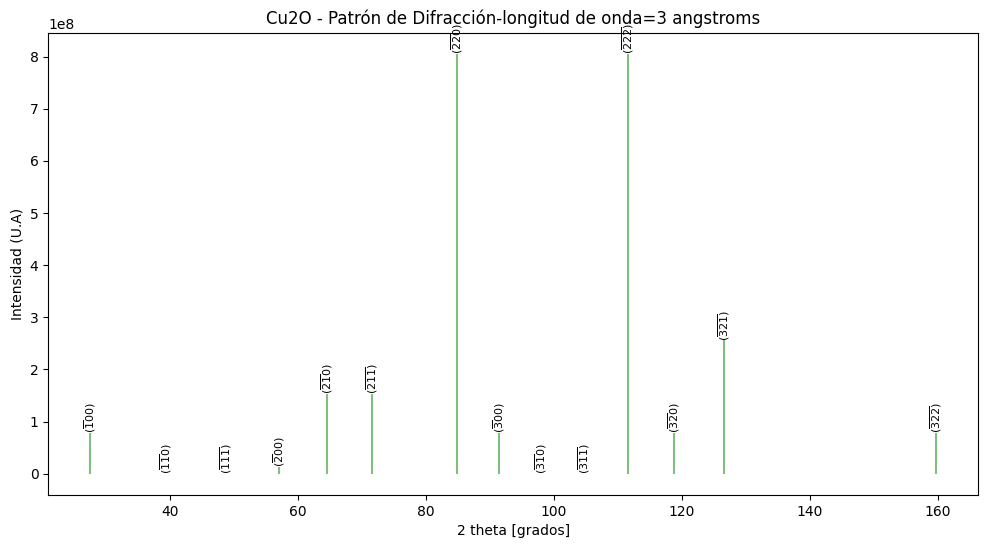

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math as mt
import cmath

#vectores de la base atómica para celdas cúbicas
#Cu, Cu2O,CuO

#Factores de forma
fCu=2.8688*10 # para Cu a 1.94 KeV
f0=8.31689 #para O a 1.94  KeV
#coordenadas de la base atomica para Cu en mp-30 (cúbica) xD Fm3-m
RCu1=np.array([0,0,0]) #cobre
RCu2=np.array([1/2,1/2,0]) #cobre
RCu3=np.array([0,1/2,1/2]) #cobre
RCu4=np.array([1/2,0,1/2])#cobre
H1=[RCu1,RCu2,RCu3,RCu4]
F1=[fCu,fCu,fCu,fCu] #factores de forma
a=1 #en angstroms parámetro de red
lamb=3 # En angstroms longitud de onda de rayos x
#Coordenadas de CuO de la base atomica para CuO en mp-14549 (cubica) Fm3-m, 8 atomos
RCuO1=np.array([0,0,0]) #Cu
RCuO2=np.array([1/2,0,1/2])#Cu
RCuO3=np.array([1/2,1/2,0])#Cu
RCuO4=np.array([0,1/2,1/2])#Cu
RCuO5=np.array([1/2,1/2,1/2])#O
RCuO6=np.array([1/2,0,0]) #O
RCuO7=np.array([0,1/2,0])#O
RCuO8=np.array([0,0,1/2])#O

F2=[fCu,fCu,fCu,fCu,f0,f0,f0,f0]
H2=[RCuO1,RCuO2,RCuO3,RCuO4,RCuO5,RCuO6,RCuO7,RCuO8]

#Coordenadas de Cu2O de la base atomica para Cu2O en mp-361 (cubica) 6 atomos
RCu2O1=np.array([1/4,1/2,0]) #cobre
RCu2O2=np.array([3/4,1/2,0]) #cobre
RCu2O3=np.array([1/2,1/4,0]) #cobre
RCu2O4=np.array([1/2,3/4,0]) #cobre
RCu2O7=np.array([0,0,0]) #oxigeno
RCu2O8=np.array([1/2,1/2,1/2]) #oxigeno

F3=[fCu,fCu,fCu,fCu,f0,f0]
H3=[RCu2O1,RCu2O2,RCu2O3,RCu2O4,RCu2O5,RCu2O6]

def norma_gene(h,k,l,V,FF): #funcion para el factor de estructura generalizando, V es un conjunto de vectores, y FF un conjunto de factores de forma
  lamb=1
  G=[h,k,l] #vector G
  m=0+0j #sumando cero para iniciar
  for i1 in range(len(V)):#corre en el conjunto de vectores de base
    for i2 in range(len(V)):
      m=m+FF[i1]*FF[i2]*cmath.exp(1j*2*np.pi*np.dot(G,V[i1]-V[i2]))#calcula la norma del factor de estructura al cuadrado
  return m.real


def formato_indices(h, k, l): #esto es para dar la notación a los índices de miller
    def formato_numero(n): # mete un indice de miller
        if n < 0:
            return f"$\overline{{{-n}}}$" #si es negativo ponle gorrito
        return str(n)

    return f"({formato_numero(h)}{formato_numero(k)}{formato_numero(l)})"



Theta=[] #aqui guardamos las productos de 2 por theta
NormaG=[] #aqui guardamos las normas de los vectores G
Millers=[] #aqui guardamos ternas de indices de miller
SG1=[] #aqui guardamos las normas al cuadrado de los factores de estructura para el Cu
SG2=[] #aqui guardamos las normas al cuadrado de los factores de estructura para el CuO
SG3=[] #aqui guardamos las normas al cuadrado de los factores de estructura para el Cu2O

Intensidad1=[] #guardamos las intensidades para el Cu
Intensidad2=[] #guardamos las intensidades para el CuO
Intensidad3=[] #guardamos las intensidades para el Cu2O

for i1 in range(-3,4): #variamos el indice h de -3 a 3
  for i2 in range(-3,4):#variamos el indice k de -3 a 3
    for i3 in range(-3,4): #variamos el indice l de -3 a 3
      if i1 == 0 and i2 == 0 and i3 == 0:
        continue  # brincate el (000)
      Sg1=norma_gene(i1,i2,i3,H1,F1) #calulamos la norma al cuadrado del factor de estructura para cada conjunto de indices (hkl) para Cu
      Sg2=norma_gene(i1,i2,i3,H2,F2) #calulamos la norma al cuadrado factor de estructura para cada conjunto de indices (hkl) para CuO
      Sg3=norma_gene(i1,i2,i3,H3,F3) #calulamos la norma al cuadrado factor de estructura para cada conjunto de indices (hkl) para Cu2O
      SG1.append(Sg1) #pegamos los valores en su respectiva lista
      SG2.append(Sg2)
      SG3.append(Sg3)
      NG=np.sqrt(i1**2+i2**2+i3**2) #Calcula la norma del vector G
      theta2=2*np.arcsin(((lamb)*NG)/(4*np.pi))*(180/np.pi) #se calcula 2*angulo en grados
      Theta.append(theta2)#pegamos los valores de 2*theta en una lista
      Intensidad1.append(Sg1*(4**6)) #calculamos la intensidad para una celda cubica FCC con 4 atomos (Cu)
      Intensidad2.append(Sg2*(8**6)) #calculamos la intensidad para una celda cubica FCC con 8 atomos (Cu)
      Intensidad3.append(Sg3*(6**6)) #calculamos la intensidad para una celda cubica FCC con 6 atomos (Cu)
      NormaG.append(NG)
      Millers.append([i1,i2,i3]) #pegamos el conjunto de indices de miller en su lista


def graficar_con_indices(theta, intensidad, millers, nombre, color): #funcion para ponerle los indices de miller a los picos
    plt.figure(figsize=(12, 6))
    normas_usadas = [] #esta lista es para guardar las normas de los indices de miller que ya se usaron, para no usar los repetidos
    for x, y, miller in zip(theta, intensidad, millers): #recorre en theta, la intensidad y los indices de miller
        norma_demillers = np.linalg.norm(miller) #calcula la norma de los indices de miller
        if norma_demillers not in normas_usadas: #si la norma no esta en el conjunto de normas usadas, entonces grafica
            plt.vlines(x=x, ymin=0, ymax=y, color=color, alpha=0.5, linestyle='-') #grafica lineas verticales desde los angulos del dominio
            plt.text(x, y - 1.05, formato_indices(*miller), ha='center', va='bottom', rotation=90, fontsize=8) #pone los indices 1.05 arribita de las lineas
            normas_usadas.append(norma_demillers) #pegamos las normas que ya usamos en la lista para no usar otro conjunto de indices equivalente
    #ploteamos
    plt.title(nombre)
    plt.xlabel("2 theta [grados]")
    plt.ylabel("Intensidad (U.A)")
    plt.show()

#llamamos a la función para Cu, CuO y Cu2O

graficar_con_indices(Theta, Intensidad1, Millers, "Cu - Patrón de Difracción-longitud de onda=3 angstroms", 'blue')
graficar_con_indices(Theta, Intensidad2, Millers, "CuO - Patrón de Difracción-longitud de onda=3 angstroms", 'red')
graficar_con_indices(Theta, Intensidad3, Millers, "Cu2O - Patrón de Difracción-longitud de onda=3 angstroms", 'green')









In [ ]:
import numpy as np

Newinten1=[]
Newinten2=[]
Newinten3=[]
#sacamos las intensidades que sean distintas de cero para usarlas para los radios de los puntitos
#multiplicamos cada valor de intensidad por un factor de 0.00000001 para disminuir el valor de la intensidad de forma proporcional para que pueda ser graficado
for i in Intensidad1:
  if i!=0:
    Newinten1.append(i*(0.00000001))

for i in Intensidad2:
  if i!=0:
    Newinten2.append(i*(0.00000001))

for i in Intensidad3:
  if i!=0:
    Newinten3.append(i*(0.00000001))

#Buscamos el valor maximo de intensidad para cada intensidad

Newinten1.index(max(Newinten1))


Newinten2.index(max(Newinten2))


Newinten3.index(max(Newinten3))



[0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401, 0.5393621608038401,

2) Una vez calculado el patron de difraccion de Rayos X, calcular los patrones de difraccion de los mismos
compuestos a lo largo de las direcciones de alta simetrıa [100], y [110]. Los resultados que se esperan tendran
una representacion similar a la figura 2. Tambien indexar los picos de difraccion como se muestra en las
imagenes.

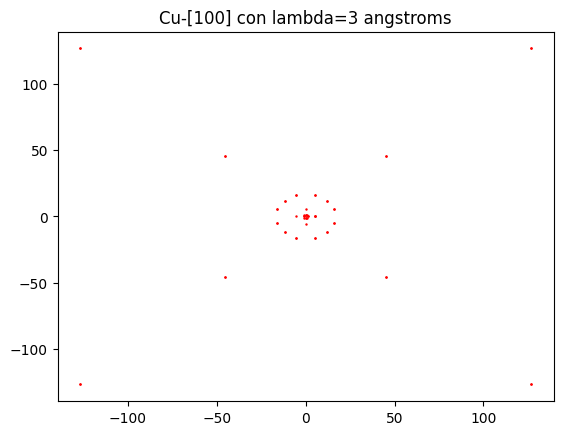

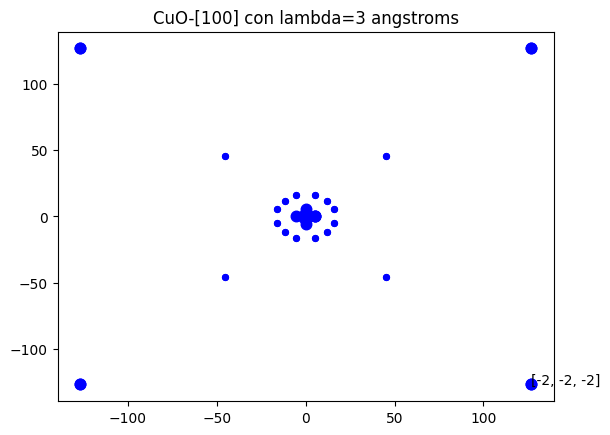

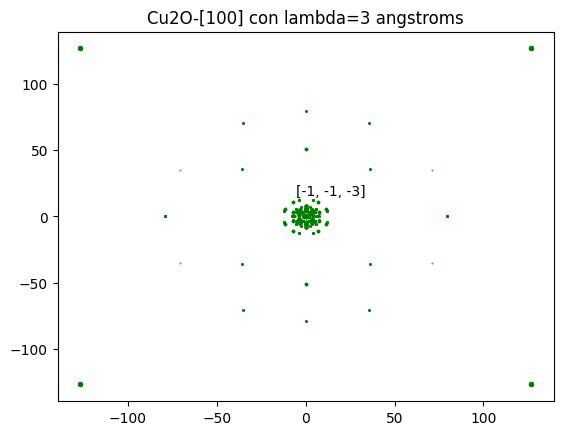

In [ ]:
import numpy as np

#Dirección [100] para Cu, CuO y Cu2O

Newtheta1=[] #extraemos los angulos para los que hay interferencia constructiva para Cu
Newtheta2=[] #extraemos los angulos para los que hay interferencia constructiva para CuO
Newtheta3=[] #extraemos los angulos para los que hay interferencia constructiva para Cu2O
#extraemos los angulos con los for para cada factor de estructura de Cu, CuO y Cu2O
for i in range(len(Theta)):
  if SG1[i]!=0:
    Newtheta1.append(Theta[i])
for i in range(len(Theta)):
  if SG2[i]!=0:
    Newtheta2.append(Theta[i])
for i in range(len(Theta)):
  if SG3[i]!=0:
    Newtheta3.append(Theta[i])

#definimos la matriz de rotación que alineará las direcciones con el haz incidente, para ello buscamos una base ortogonal
def Rotacion(u,v): #creamos la matriz de rotacion para alinear las direcciones de alta simetria con el vector ortogonal al detector (paralelo al haz incidente)
  x3=np.array(u)/np.linalg.norm(np.array(u)) #Este vector será nuestro eje z alineado con la dirección en la que queremos ver al cristal
  x1=np.cross(v,x3)/np.linalg.norm(np.cross(v,x3)) #usamos otro vector v ortogonal a u, y creamos otro vector para la matriz de rotación
  x2=np.cross(x3,x1)/np.linalg.norm(np.cross(x3,x1)) #construimos con x3 y x1 el tercer vector de nuestra matriz de rotación para rotar los ejes en el cristal (de direcciones) con los del detetector
  R=np.array([x1,x2,x3]) #construimos la matriz con los vectores obtenidos apartir de u y v, con u las direcciones de alta simetría ([100] y [110])
  return R

#En estas listas guardamos el conjunto de indices de miller para los que se logró una norma al cuadrado del factor de estructura distinto de cero
NewMillers1=[] #millers para Cu
NewMillers2=[] #millers para CuO
NewMillers3=[] #millers para Cu2O
for i in range(len(Millers)):
  if SG1[i]!=0:
    NewMillers1.append(Millers[i])
for i in range(len(Millers)):
  if SG2[i]!=0:
    NewMillers2.append(Millers[i])

for i in range(len(Millers)):
  if SG3[i]!=0:
    NewMillers3.append(Millers[i])

#En las listas V1,V2 y V3, vamos a guardar los productos de la matriz de rotación con el vector G para obtener las coordenadas de G en el sistema del detector
V1=[]
V2=[]
V3=[]
for i in NewMillers1:
  o1=np.dot(Rotacion([1,0,0],[0,1,0]),i)
  V1.append(o1)
for i in NewMillers2:
  o2=np.dot(Rotacion([1,0,0],[0,1,0]),i)
  V2.append(o2)
for i in NewMillers3:
  o3=np.dot(Rotacion([1,0,0],[0,1,0]),i)
  V3.append(o3)
#En las listas Phi, guardamos los ángulos en el sistema del detector para localizar cada punto del patron (son como los del plano polar pero el origen es el punto donde el haz incidente llega al detector)
Phi1=[] #para Cu
Phi2=[] #para CuO
Phi3=[] #para Cu2O

#calculamos los angulos phi, que son los que forman las componentes x, y del vector G en el sistema del detector (donde G no es normal al detector)
for i in range(len(V1)):
  Phi1.append(np.arctan2(V1[i][0],V1[i][1]))
  Phi2.append(np.arctan2(V2[i][0],V2[i][1]))
for i in range(len(V3)):
  Phi3.append(np.arctan2(V3[i][0],V3[i][1]))
#En las listas de X y Y, guardaremos las coordenadas en el sistema de laboratorio para cada uno de los puntos luminosos (para graficar los puntitos en R2)
X1=[] #para Cu
Y1=[] #para Cu

X2=[] #para CuO
Y2=[] #para CuO

X3=[]#para Cu2O
Y3=[] #para Cu2O
l=10 #distancia desde el punto donde incide el haz hasta el atomo desde donde vino (distancia detector-atomo medida en nm)

#calculamos las coordenadas para cada punto del patron de difracción
for i in range(len(Phi1)):
  X1.append(l*np.tan(Newtheta1[i])*np.cos(Phi1[i])) #Cu
  Y1.append(l*np.tan(Newtheta1[i])*np.sin(Phi1[i]))#Cu
  X2.append(l*np.tan(Newtheta2[i])*np.cos(Phi2[i])) #CuO
  Y2.append(l*np.tan(Newtheta2[i])*np.sin(Phi2[i]))#CuO
for i in range(len(Phi3)):
  X3.append(l*np.tan(Newtheta3[i])*np.cos(Phi3[i]))#Cu2O
  Y3.append(l*np.tan(Newtheta3[i])*np.sin(Phi3[i]))#Cu2O

#graficamos el patron de difracción como puntitos, omitiremos por ahora el grosor de cada puntito
for i in range(len(Newinten1)):
  plt.scatter(X1[i],Y1[i],color="red",s=Newinten1[i])
plt.text(X1[40],Y1[40],NewMillers1[40])
plt.title("Cu-[100] con lambda=3 angstroms")
plt.show()

for i in range(len(Newinten2)):
  plt.scatter(X2[i],Y2[i],color="blue",s=Newinten2[i])
plt.text(X1[16],Y1[16],NewMillers2[16])
plt.title("CuO-[100] con lambda=3 angstroms")
plt.show()

for i in range(len(Newinten3)):
  plt.scatter(X3[i],Y3[i],color="green",s=Newinten3[i])
plt.text(X1[29],Y1[29],NewMillers2[29])
plt.title("Cu2O-[100] con lambda=3 angstroms")
plt.show()

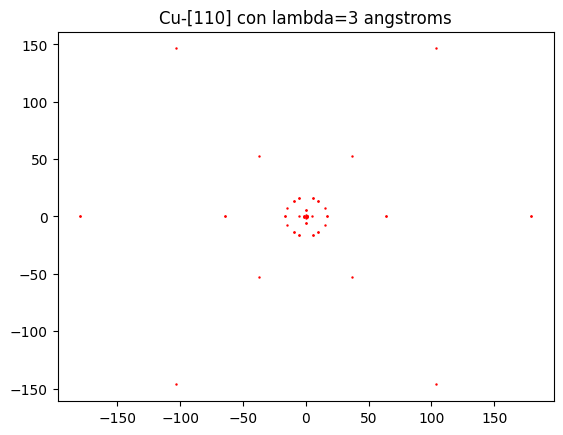

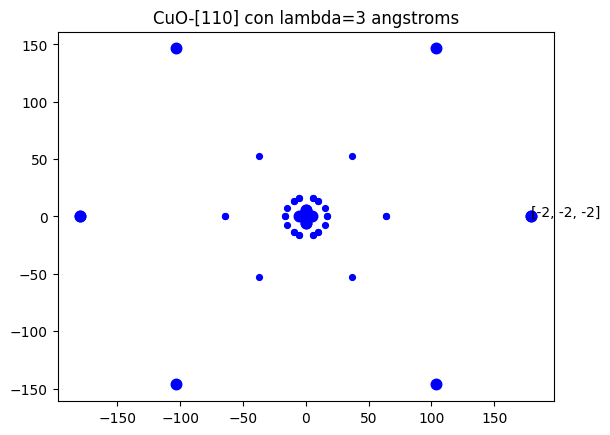

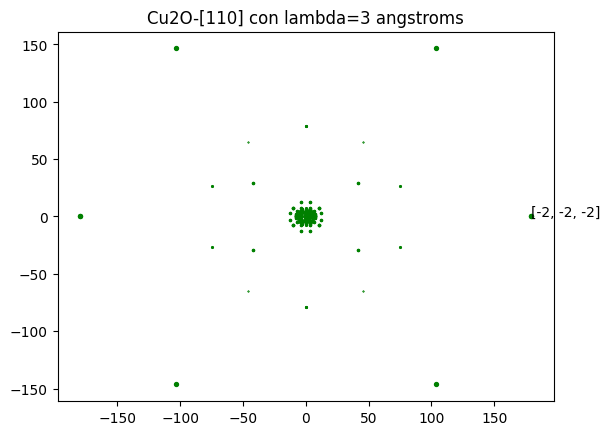

In [ ]:
import numpy as np

#Dirección [110] para Cu, CuO y Cu2O

#Nuevamente las listas V, son para guardar las componentes del vector G en las coordenadas del sistema de laboratorio
V1=[] #para Cu
V2=[]#para CuO
V3=[]#para Cu2O
#calculamos las componentes de cada G, en la dirreción de alta simetría [110], tomamos un vector ortogonal [001] para que la funcion construya otra matriz de rotación para estas direcciones
for i in NewMillers1:
  o1=np.dot(Rotacion([1,1,0],[0,0,1]),i)
  V1.append(o1)
for i in NewMillers2:
  o2=np.dot(Rotacion([1,1,0],[0,0,1]),i)
  V2.append(o2)
for i in NewMillers3:
  o3=np.dot(Rotacion([1,1,0],[0,0,1]),i)
  V3.append(o3)

#nuevamente son listas para guardar los angulos phi, medidos en el sistema del detector para localizar a cada punto en el detector (no son los theta)
Phi1=[]#para Cu
Phi2=[] #para CuO
Phi3=[]#para Cu2O

#pegamos los angulos phi, tomando el arcotangente de las componentes de y,x del vector G en el sistema de laboratorio
for i in range(len(V1)):
  Phi1.append(np.arctan2(V1[i][0],V1[i][1]))
  Phi2.append(np.arctan2(V2[i][0],V2[i][1]))
for i in range(len(V3)):
  Phi3.append(np.arctan2(V3[i][0],V3[i][1]))
#coordenadas de cada punto luminoso en el detector
X1=[] #Cu
Y1=[] #Cu

X2=[] #CuO
Y2=[]#CuO

X3=[] #Cu2O
Y3=[] #Cu2O
l=10 #distancia al detector en nm
#calculamos las coordenadas de los puntos luminosos en el sistema del detector
for i in range(len(Phi1)):
  X1.append(l*np.tan(Newtheta1[i])*np.cos(Phi1[i])) #Cu
  Y1.append(l*np.tan(Newtheta1[i])*np.sin(Phi1[i]))#Cu
  X2.append(l*np.tan(Newtheta2[i])*np.cos(Phi2[i]))#CuO
  Y2.append(l*np.tan(Newtheta2[i])*np.sin(Phi2[i])) #CuO
for i in range(len(Phi3)):
  X3.append(l*np.tan(Newtheta3[i])*np.cos(Phi3[i]))#Cu2O
  Y3.append(l*np.tan(Newtheta3[i])*np.sin(Phi3[i]))#Cu2O

#graficamos el patron de difracción como puntitos, dandole un tamaño proporcional a su intensidad
for i in range(len(Newinten1)):
  plt.scatter(X1[i],Y1[i],color="red",s=Newinten1[i])
plt.text(X1[40],Y1[40],NewMillers1[40])
plt.title("Cu-[110] con lambda=3 angstroms")
plt.show()

for i in range(len(Newinten2)):
  plt.scatter(X2[i],Y2[i],color="blue",s=Newinten2[i])
plt.text(X2[16],Y2[16],NewMillers2[16])
plt.title("CuO-[110] con lambda=3 angstroms")
plt.show()

for i in range(len(Newinten3)):
  plt.scatter(X3[i],Y3[i],color="green",s=Newinten3[i])
plt.text(X3[29],Y3[29],NewMillers3[29])
plt.title("Cu2O-[110] con lambda=3 angstroms")
plt.show()